In [11]:
pip install seaborn


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

In [198]:
# Load the weather data
weather_file_path = '/Users/amyxqc/Desktop/amy_bikenycfall2024/Data/indep_weather.csv'
weather_data = pd.read_csv(weather_file_path)

# Check the first few entries of the DATE column
print(weather_data['DATE'].head(10))

0    2021-01-01
1    2021-01-02
2    2021-01-03
3    2021-01-04
4    2021-01-05
5    2021-01-06
6    2021-01-07
7    2021-01-08
8    2021-01-09
9    2021-01-10
Name: DATE, dtype: object


In [199]:

# Convert DATE column to datetime
try:
    if pd.api.types.is_numeric_dtype(weather_data['DATE']):
        # Handle Excel serial numbers
        weather_data['DATE'] = pd.to_datetime('1899-12-30') + pd.to_timedelta(weather_data['DATE'], unit='D')
    else:
        # Try parsing with automatic detection
        weather_data['DATE'] = pd.to_datetime(weather_data['DATE'], errors='coerce')
except Exception as e:
    print(f"Error converting DATE column: {e}")

# Drop rows with invalid dates
weather_data.dropna(subset=['DATE'], inplace=True)

# Display the converted DATE column
print("Converted DATE column:")
print(weather_data['DATE'].head())

Converted DATE column:
0   2021-01-01
1   2021-01-02
2   2021-01-03
3   2021-01-04
4   2021-01-05
Name: DATE, dtype: datetime64[ns]


In [200]:
print (weather_data)

          STATION                         NAME  LATITUDE  LONGITUDE  \
0     USW00094728  NY CITY CENTRAL PARK, NY US  40.77898  -73.96925   
1     USW00094728  NY CITY CENTRAL PARK, NY US  40.77898  -73.96925   
2     USW00094728  NY CITY CENTRAL PARK, NY US  40.77898  -73.96925   
3     USW00094728  NY CITY CENTRAL PARK, NY US  40.77898  -73.96925   
4     USW00094728  NY CITY CENTRAL PARK, NY US  40.77898  -73.96925   
...           ...                          ...       ...        ...   
1425  USW00094728  NY CITY CENTRAL PARK, NY US  40.77898  -73.96925   
1426  USW00094728  NY CITY CENTRAL PARK, NY US  40.77898  -73.96925   
1427  USW00094728  NY CITY CENTRAL PARK, NY US  40.77898  -73.96925   
1428  USW00094728  NY CITY CENTRAL PARK, NY US  40.77898  -73.96925   
1429  USW00094728  NY CITY CENTRAL PARK, NY US  40.77898  -73.96925   

      ELEVATION       DATE  AWND AWND_ATTRIBUTES  PGTM PGTM_ATTRIBUTES  ...  \
0          42.7 2021-01-01  5.59             ,,W   NaN             N

In [206]:
# Drop rows with invalid dates
weather_data = weather_data.dropna(subset=['DATE'])

# Extract year and ISO week number (aligned with ISO weeks)
weather_data['year'] = weather_data['DATE'].dt.year
weather_data['week_number'] = weather_data['DATE'].dt.isocalendar().week

## Define start date (January 1, 2021)
start_date = pd.Timestamp('2021-01-01')

# Calculate continuous week number from start_date
weather_data['week_number'] = ((weather_data['DATE'] - start_date).dt.days // 7) + 1

# Calculate daily average temperature if columns are present
if 'TMIN' in weather_data.columns and 'TMAX' in weather_data.columns:
    weather_data['TAVG'] = (weather_data['TMIN'] + weather_data['TMAX']) / 2
else:
    print("Temperature columns TMIN and TMAX are missing from the dataset.")

# Group by continuous week number and calculate weekly averages
weekly_weather = weather_data.groupby('week_number').agg(
    avg_precipitation=('PRCP', 'mean'),  # Average precipitation
    avg_snow=('SNOW', 'mean'),          # Average snow depth
    avg_temperature=('TAVG', 'mean'),   # Average temperature
    avg_wind_speed=('WSF2', 'mean')     # Average wind speed
).reset_index()

# Fill missing data (e.g., weeks with no data)
weekly_weather.fillna(0, inplace=True)

# Display the aggregated weekly weather data
print("Weekly Weather Data")
print(weekly_weather)

Weekly Weather Data
     week_number  avg_precipitation  avg_snow  avg_temperature  avg_wind_speed
0              1           0.130000  0.000000        38.142857       16.042857
1              2           0.000000  0.000000        35.928571       11.585714
2              3           0.168571  0.000000        38.714286       18.042857
3              4           0.014286  0.014286        31.571429       18.014286
4              5           0.301429  2.485714        28.071429       17.857143
..           ...                ...       ...              ...             ...
200          201           0.000000  0.000000        59.857143       13.200000
201          202           0.025714  0.000000        50.928571       16.328571
202          203           0.224286  0.000000        52.785714       14.928571
203          204           0.228571  0.000000        46.071429       15.628571
204          205           0.000000  0.000000        37.500000       14.550000

[205 rows x 5 columns]


In [207]:
# Save the result to a file if needed
output_file_path = '/Users/amyxqc/Desktop/amy_bikenycfall2024/Data/weekly_weather.csv'
weekly_weather.to_csv(output_file_path, index=False)
print(f"Weekly weather data saved to {output_file_path}")

Weekly weather data saved to /Users/amyxqc/Desktop/amy_bikenycfall2024/Data/weekly_weather.csv


In [208]:
# Path to your saved CSV file
csv_file_path = '/Users/amyxqc/Desktop/amy_bikenycfall2024/Data/Final/final_weekly_data.csv'  # Replace with your actual file path

# Read the CSV file into a DataFrame
final_weekly_data_final = pd.read_csv(csv_file_path)

# Display the first few rows of the DataFrame to verify
print(final_weekly_data_final)

     year  week_number    borough  total_trips  weekday_trips  weekend_trips  \
0    2021            1      Bronx          544            404            140   
1    2021            1   Brooklyn        27858          20350           7508   
2    2021            1  Manhattan       197947         149658          48289   
3    2021            2      Bronx          533            410            123   
4    2021            2   Brooklyn        34343          24741           9602   
..    ...          ...        ...          ...            ...            ...   
798  2024          195     Queens        15154          10671           4483   
799  2024          196      Bronx         5347           3722           1625   
800  2024          196   Brooklyn        94233          60554          33679   
801  2024          196  Manhattan       403838         279903         123935   
802  2024          196     Queens         6503           4341           2162   

     avg_daily_trips  avg_weekday_trips

In [211]:
# Assuming 'final_weekly_data_final' contains the Citibike weekly data
# and 'weekly_weather' contains the weather data

# Merge weather data with Citibike data on 'year' and 'week_number'
combined_data = pd.merge(final_weekly_data_final, weekly_weather, on=['week_number'], how='left')

# Verify the merge operation
print("Merged data preview:")
print(combined_data)  # Display the first few rows to verify



Merged data preview:
     year  week_number    borough  total_trips  weekday_trips  weekend_trips  \
0    2021            1      Bronx          544            404            140   
1    2021            1   Brooklyn        27858          20350           7508   
2    2021            1  Manhattan       197947         149658          48289   
3    2021            2      Bronx          533            410            123   
4    2021            2   Brooklyn        34343          24741           9602   
..    ...          ...        ...          ...            ...            ...   
798  2024          195     Queens        15154          10671           4483   
799  2024          196      Bronx         5347           3722           1625   
800  2024          196   Brooklyn        94233          60554          33679   
801  2024          196  Manhattan       403838         279903         123935   
802  2024          196     Queens         6503           4341           2162   

     avg_daily_tri

In [214]:
print(combined_data)

     year  week_number    borough  total_trips  weekday_trips  weekend_trips  \
0    2021            1      Bronx          544            404            140   
1    2021            1   Brooklyn        27858          20350           7508   
2    2021            1  Manhattan       197947         149658          48289   
3    2021            2      Bronx          533            410            123   
4    2021            2   Brooklyn        34343          24741           9602   
..    ...          ...        ...          ...            ...            ...   
798  2024          195     Queens        15154          10671           4483   
799  2024          196      Bronx         5347           3722           1625   
800  2024          196   Brooklyn        94233          60554          33679   
801  2024          196  Manhattan       403838         279903         123935   
802  2024          196     Queens         6503           4341           2162   

     avg_daily_trips  avg_weekday_trips

In [213]:
# Save the combined data to a CSV file
output_file_path = '/Users/amyxqc/Desktop/amy_bikenycfall2024/Data/final_combined_data_with_weather.csv'  # Replace with your desired output path
combined_data.to_csv(output_file_path, index=False)

In [217]:
# Define columns to aggregate
columns_to_aggregate = [
    'avg_daily_trips',
    'avg_weekday_trips',
    'avg_weekend_trips',
    'avg_precipitation',
    'avg_snow',
    'avg_temperature',
    'avg_wind_speed'
]

# Define the aggregation functions
agg_funcs = {col: ['min', 'max', 'mean', 'std'] for col in columns_to_aggregate}

# Group by borough, calculate min, max, mean, and std across all weeks
borough_stats = combined_data.groupby('borough').agg(agg_funcs)

# Flatten the MultiIndex columns
borough_stats.columns = ['_'.join(col).strip() for col in borough_stats.columns.values]
borough_stats = borough_stats.reset_index()

# Save the borough statistics to a new CSV file
output_file_path = '/Users/amyxqc/Desktop/amy_bikenycfall2024/Data/borough_stats_overall.csv'
borough_stats.to_csv(output_file_path, index=False)

# Display a sample of the resulting stats
print("Overall Borough Statistics (All Weeks Combined):")
print(borough_stats.head())
print(f"Overall statistics saved to {output_file_path}")



Overall Borough Statistics (All Weeks Combined):
     borough  avg_daily_trips_min  avg_daily_trips_max  avg_daily_trips_mean  \
0      Bronx            21.000000          1757.142857            649.887294   
1   Brooklyn          1071.857143         31843.428571          14125.516152   
2  Manhattan          5682.857143        145671.428571          74722.395549   
3      Other             0.142857             0.571429              0.333333   
4     Queens             0.428571          2273.857143            463.540659   

   avg_daily_trips_std  avg_weekday_trips_min  avg_weekday_trips_max  \
0           436.521295                   11.0                 1858.6   
1          6581.176392                 1024.4                30967.4   
2         29305.236104                 7956.0               149042.2   
3             0.174964                    0.0                    0.8   
4           655.499608                    0.6                 2299.8   

   avg_weekday_trips_mean  avg_weekda

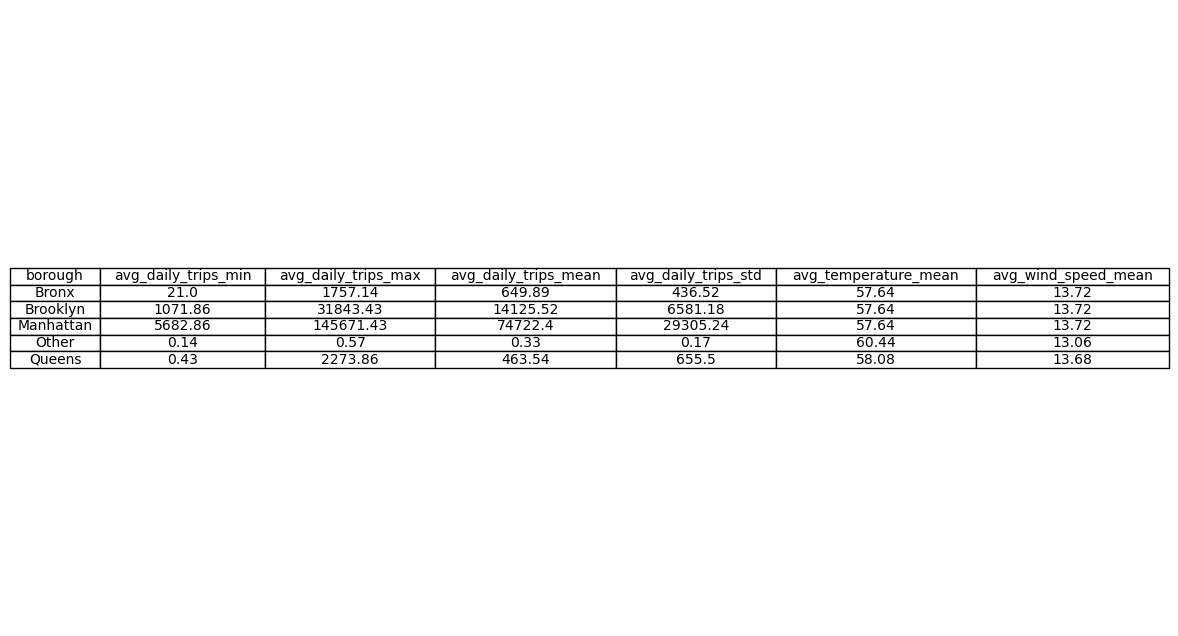

In [219]:
import pandas as pd
import matplotlib.pyplot as plt

# Define the data
data = {
    "borough": ["Bronx", "Brooklyn", "Manhattan", "Other", "Queens"],
    "avg_daily_trips_min": [21.0, 1071.86, 5682.86, 0.14, 0.43],
    "avg_daily_trips_max": [1757.14, 31843.43, 145671.43, 0.57, 2273.86],
    "avg_daily_trips_mean": [649.89, 14125.52, 74722.40, 0.33, 463.54],
    "avg_daily_trips_std": [436.52, 6581.18, 29305.24, 0.17, 655.50],
    "avg_temperature_mean": [57.64, 57.64, 57.64, 60.44, 58.08],
    "avg_wind_speed_mean": [13.72, 13.72, 13.72, 13.06, 13.68],
}

# Create a DataFrame
table_data = pd.DataFrame(data)

# Create a figure and axis for the table
fig, ax = plt.subplots(figsize=(14, 8))
ax.axis('tight')
ax.axis('off')

# Create a table from the DataFrame
table = ax.table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    cellLoc='center',
    loc='center'
)

# Adjust table appearance
table.auto_set_font_size(False)
table.set_fontsize(10)
table.auto_set_column_width(col=list(range(len(table_data.columns))))




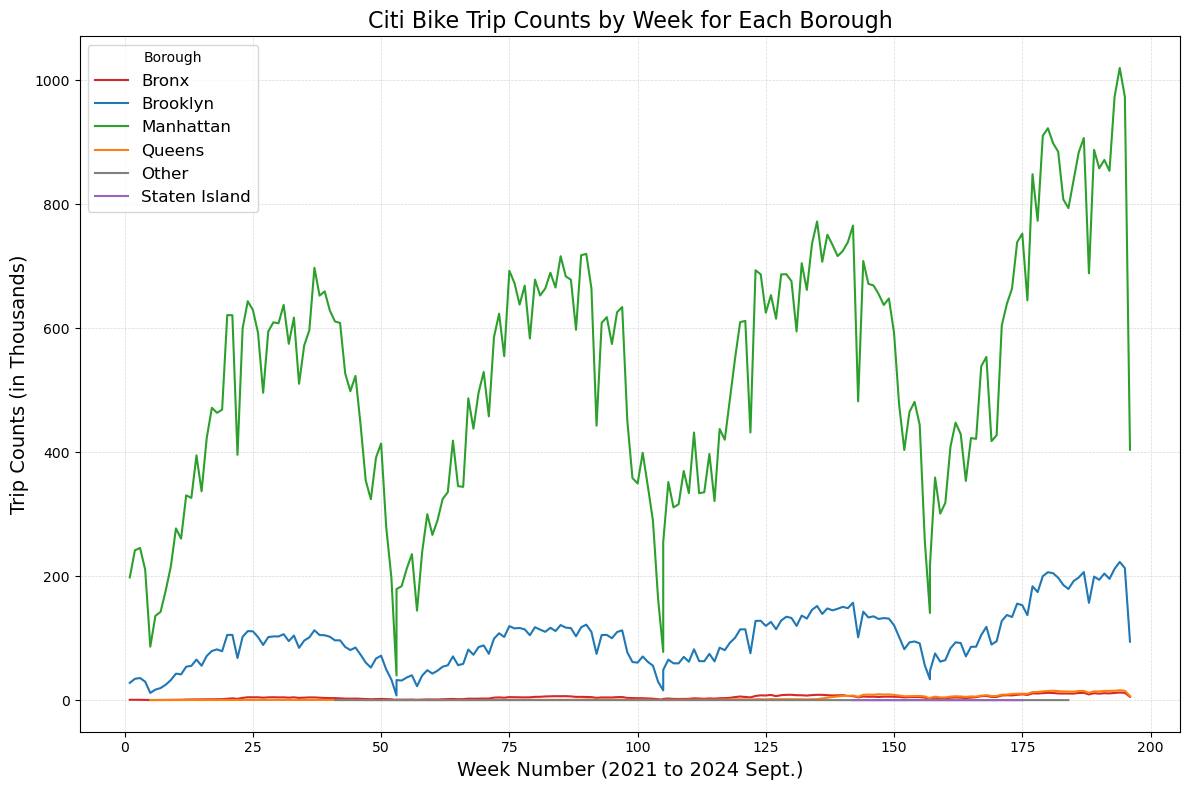

In [33]:
# Define custom colors
custom_colors = {
    'Manhattan': '#2ca02c',  # Beautiful green
    'Brooklyn': '#1f77b4',   # Blue
    'Queens': '#ff7f0e',     # Orange
    'Bronx': '#d62728',      # Red
    'Staten Island': '#9467bd'  # Purple
}

# Create the plot
plt.figure(figsize=(12, 8))  # Set figure size

# Plot each borough's trips as a line
for borough in final_weekly_data['borough'].unique():
    subset = final_weekly_data[final_weekly_data['borough'] == borough]
    plt.plot(subset['week_number'], subset['total_trips'] / 1000, 
             label=borough, color=custom_colors.get(borough, 'gray'))

# Add labels and title
plt.title('Citi Bike Trip Counts by Week for Each Borough', fontsize=16)
plt.xlabel('Week Number (2021 to 2024 Sept.)', fontsize=14)
plt.ylabel('Trip Counts (in Thousands)', fontsize=14)

# Add gridlines with lighter transparency
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.3)  # Adjust grid appearance

# Add a legend
plt.legend(title='Borough', loc='upper left', fontsize=12)

# Adjust layout for better display
plt.tight_layout()

# Show the plot
plt.show()


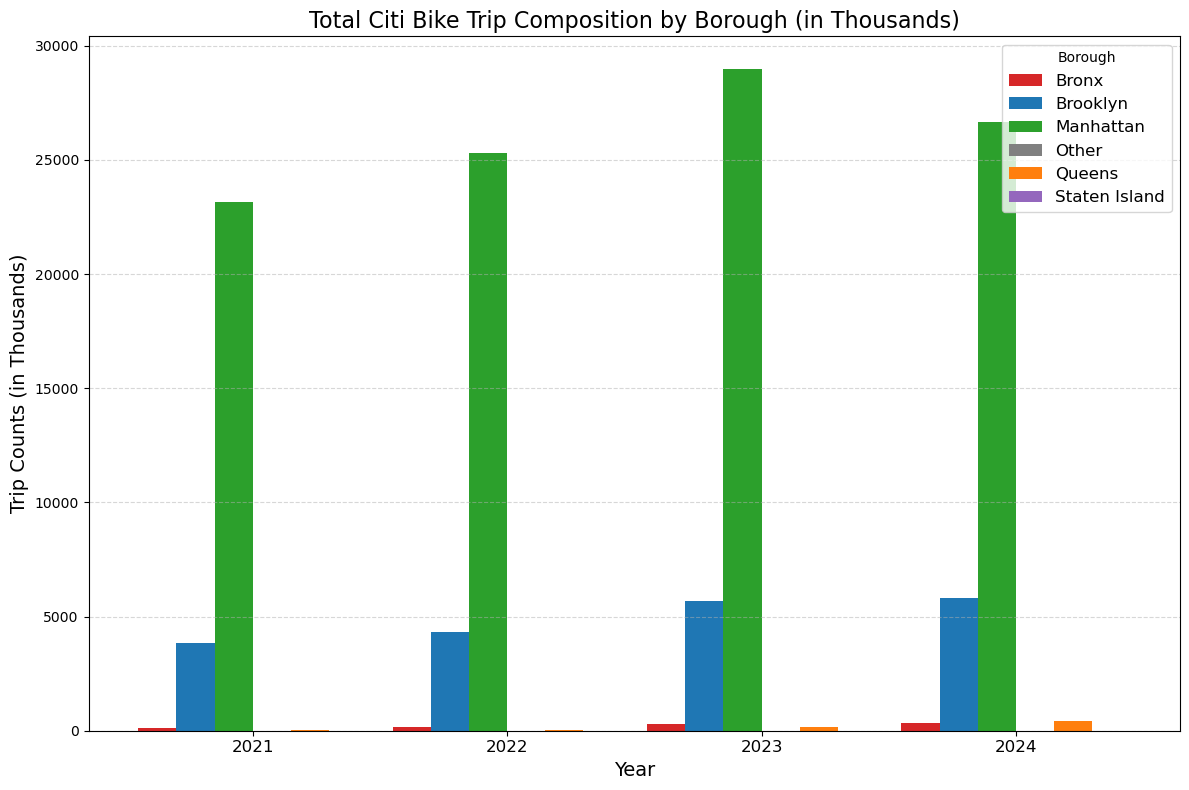

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# Aggregate total trips for each borough by year
yearly_borough_data = final_weekly_data.groupby(['year', 'borough'])['total_trips'].sum().unstack()

# Define custom colors for the bars (use the same colors as the line chart)
custom_colors = {
    'Manhattan': '#2ca02c',  # Beautiful green
    'Brooklyn': '#1f77b4',   # Blue
    'Queens': '#ff7f0e',     # Orange
    'Bronx': '#d62728',      # Red
    'Staten Island': '#9467bd'  # Purple
}

# Map boroughs to colors
colors = [custom_colors.get(borough, 'gray') for borough in yearly_borough_data.columns]

# Create a bar chart
fig, ax = plt.subplots(figsize=(12, 8))

# Define bar width and positions
bar_width = 0.15
positions = np.arange(len(yearly_borough_data.index))

# Plot each borough as a separate bar
for i, borough in enumerate(yearly_borough_data.columns):
    ax.bar(
        positions + i * bar_width, 
        yearly_borough_data[borough] / 1000,  # Convert trips to thousands
        width=bar_width, 
        label=borough, 
        color=custom_colors.get(borough, 'gray')
    )

# Add labels, title, and legend
ax.set_title('Total Citi Bike Trip Composition by Borough (in Thousands)', fontsize=16)
ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('Trip Counts (in Thousands)', fontsize=14)
ax.set_xticks(positions + bar_width * (len(yearly_borough_data.columns) - 1) / 2)
ax.set_xticklabels(yearly_borough_data.index, fontsize=12)  # Year labels
ax.legend(title='Borough', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

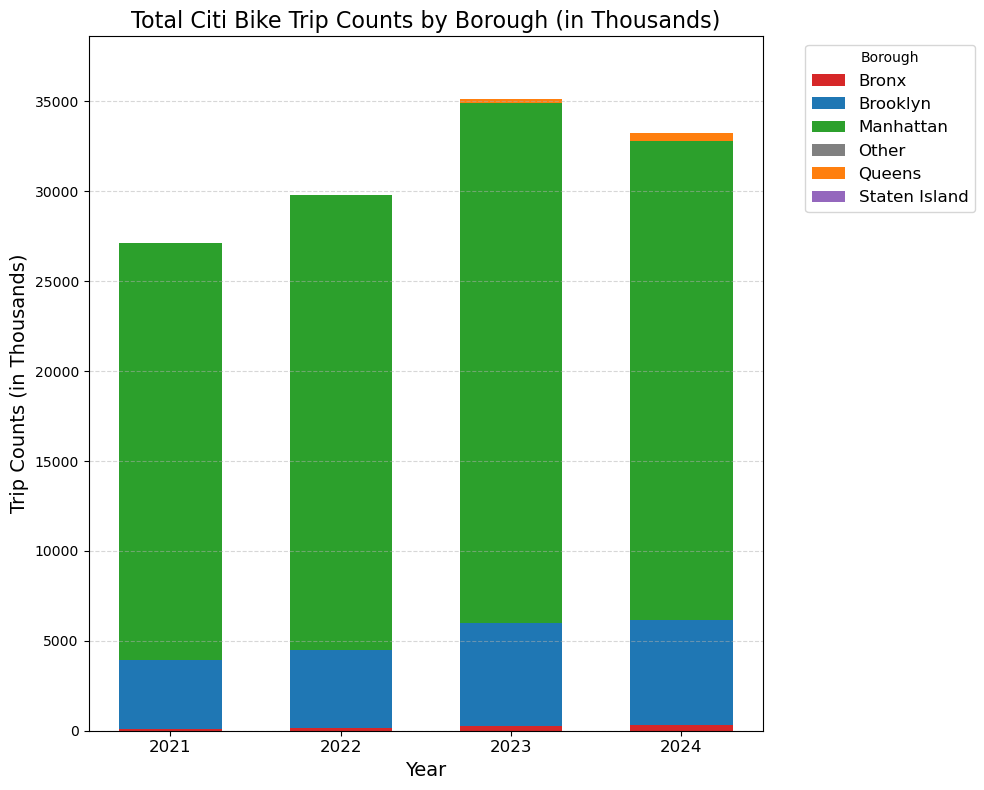

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# Aggregate total trips for each borough by year
yearly_borough_data = final_weekly_data.groupby(['year', 'borough'])['total_trips'].sum().unstack()

# Define custom colors for the bars with Manhattan as green and Brooklyn as blue
custom_colors = {
    'Manhattan': '#2ca02c',  # Beautiful green
    'Brooklyn': '#1f77b4',   # Blue
    'Queens': '#ff7f0e',     # Orange
    'Bronx': '#d62728',      # Red
    'Staten Island': '#9467bd'  # Purple
}

# Map boroughs to colors
colors = [custom_colors.get(borough, 'gray') for borough in yearly_borough_data.columns]

# Create the plot
fig, ax = plt.subplots(figsize=(10, 8))

# Plot stacked bars
bottoms = np.zeros(len(yearly_borough_data))
bar_width = 0.6  # Set bar width to make bars thinner
for borough, color in zip(yearly_borough_data.columns, colors):
    ax.bar(
        yearly_borough_data.index, 
        yearly_borough_data[borough] / 1000,  # Convert trip counts to thousands
        width=bar_width,  # Adjust bar width
        label=borough, 
        color=color, 
        bottom=bottoms
    )
    bottoms += yearly_borough_data[borough] / 1000  # Update the bottom for the next stack

# Add labels, title, and legend
ax.set_title('Total Citi Bike Trip Counts by Borough (in Thousands)', fontsize=16)
ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('Trip Counts (in Thousands)', fontsize=14)
ax.set_xticks(yearly_borough_data.index)
ax.set_xticklabels(yearly_borough_data.index, fontsize=12)

# Move the legend outside the plot
ax.legend(
    title='Borough', 
    loc='upper left', 
    bbox_to_anchor=(1.05, 1),  # Place it outside the plot
    fontsize=12
)

# Add a small padding to the top of the y-axis
max_value = (yearly_borough_data.sum(axis=1).max()) / 1000
plt.ylim(0, max_value * 1.1)  # Add 10% padding above the highest bar

plt.grid(axis='y', linestyle='--', alpha=0.5)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()



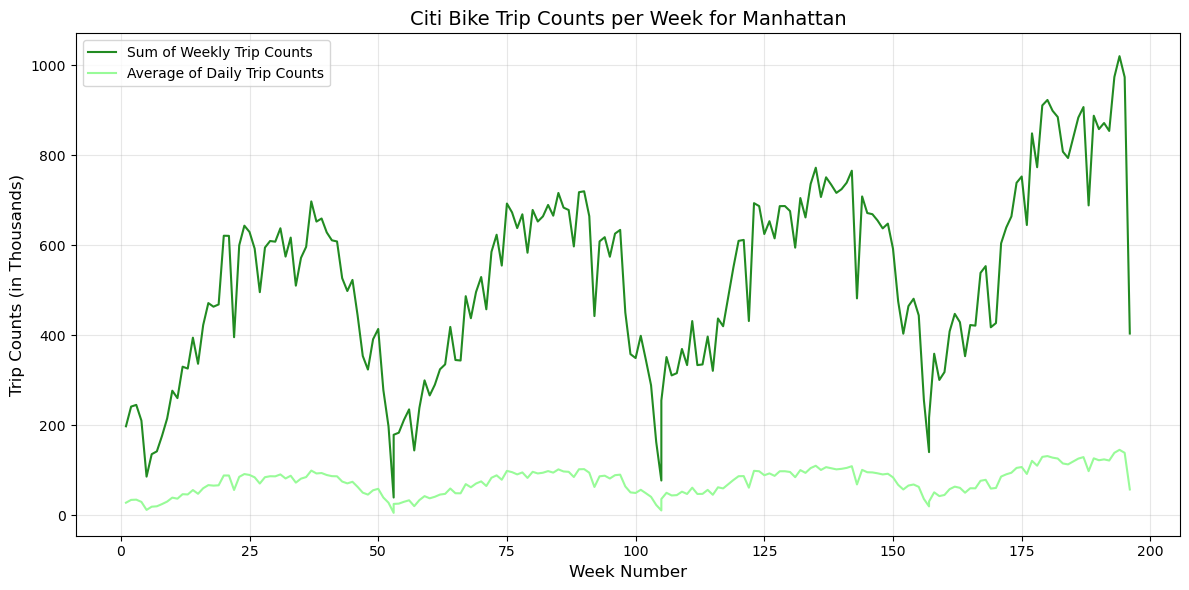

In [40]:
import matplotlib.pyplot as plt

# Filter the data for Manhattan
manhattan_data = combined_data[combined_data['borough'] == 'Manhattan']

# Create a figure
plt.figure(figsize=(12, 6))

# Plot the sum of total trips per week
plt.plot(manhattan_data['week_number'], manhattan_data['total_trips']/1000, label='Sum of Weekly Trip Counts', color='#228B22')

# Plot the average daily trips multiplied by 7 for comparison with weekly sums
plt.plot(manhattan_data['week_number'], manhattan_data['avg_daily_trips']/1000, label='Average of Daily Trip Counts', color='#98FB98')

# Add labels and title
plt.title('Citi Bike Trip Counts per Week for Manhattan', fontsize=14)
plt.xlabel('Week Number', fontsize=12)
plt.ylabel('Trip Counts (in Thousands)', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(alpha=0.3)

# Add a legend
plt.legend(loc='upper left', fontsize=10)

# Show the plot
plt.tight_layout()
plt.show()


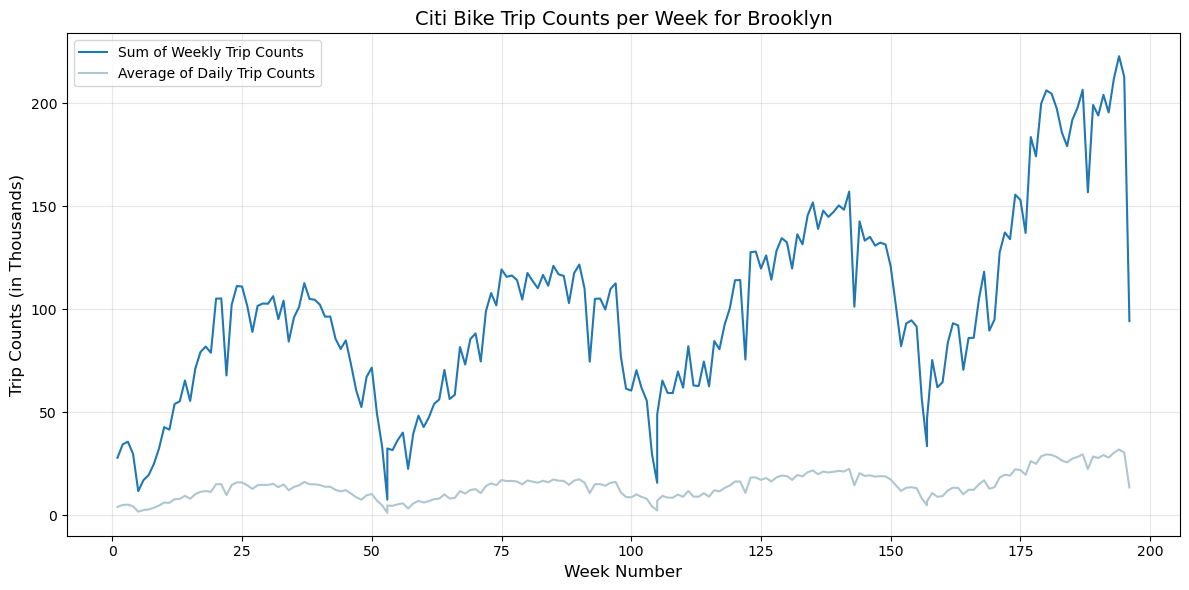

In [41]:
import matplotlib.pyplot as plt

# Filter the data for Manhattan
brooklyn_data = combined_data[combined_data['borough'] == 'Brooklyn']

# Create a figure
plt.figure(figsize=(12, 6))

# Plot the sum of total trips per week
plt.plot(brooklyn_data['week_number'], brooklyn_data['total_trips']/1000, label='Sum of Weekly Trip Counts', color='#1f77b4')

# Plot the average daily trips multiplied by 7 for comparison with weekly sums
plt.plot(brooklyn_data['week_number'], brooklyn_data['avg_daily_trips']/1000, label='Average of Daily Trip Counts', color='#AEC6CF')

# Add labels and title
plt.title('Citi Bike Trip Counts per Week for Brooklyn', fontsize=14)
plt.xlabel('Week Number', fontsize=12)
plt.ylabel('Trip Counts (in Thousands)', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(alpha=0.3)

# Add a legend
plt.legend(loc='upper left', fontsize=10)

# Show the plot
plt.tight_layout()
plt.show()

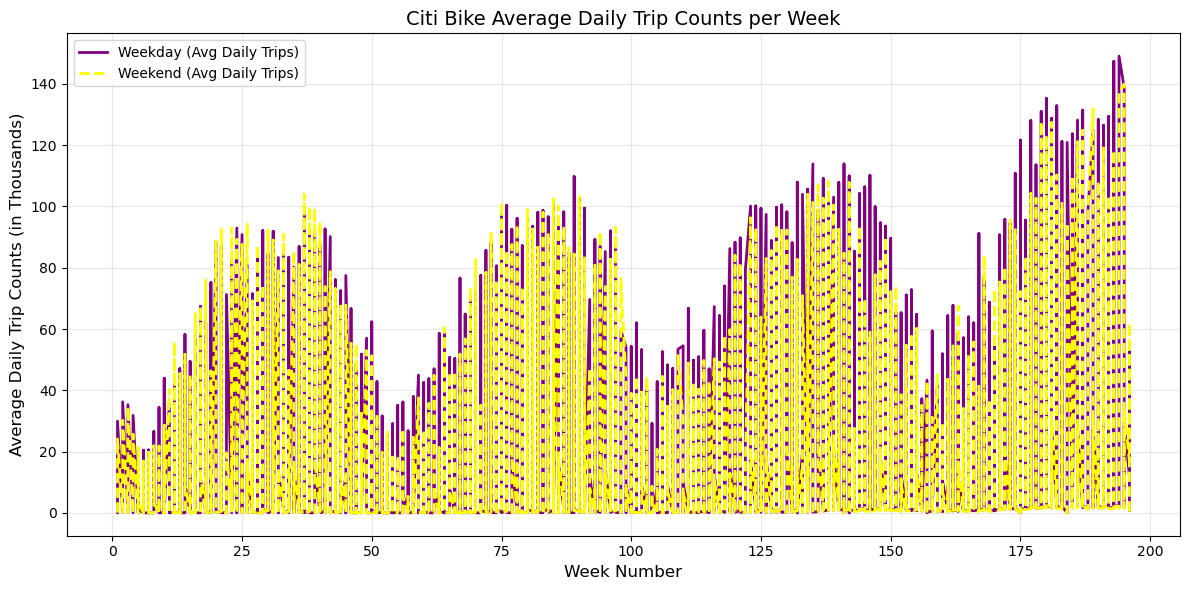

In [47]:
import matplotlib.pyplot as plt

# Ensure the data is sorted and remove duplicates
filtered_data = combined_data[['week_number', 'avg_weekday_trips', 'avg_weekend_trips']].drop_duplicates()
filtered_data = filtered_data.sort_values(by='week_number').dropna()

# Ensure `week_number` is numeric
filtered_data['week_number'] = pd.to_numeric(filtered_data['week_number'], errors='coerce')

# Create a figure
plt.figure(figsize=(12, 6))

# Plot average weekday trip counts (Purple)
plt.plot(filtered_data['week_number'], filtered_data['avg_weekday_trips'] / 1000, 
         label='Weekday (Avg Daily Trips)', color='purple', linewidth=2)

# Plot average weekend trip counts (Yellow)
plt.plot(filtered_data['week_number'], filtered_data['avg_weekend_trips'] / 1000, 
         label='Weekend (Avg Daily Trips)', color='yellow', linestyle='--', linewidth=2)

# Add labels and title
plt.title('Citi Bike Average Daily Trip Counts per Week', fontsize=14)
plt.xlabel('Week Number', fontsize=12)
plt.ylabel('Average Daily Trip Counts (in Thousands)', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(alpha=0.3)

# Add a legend
plt.legend(loc='upper left', fontsize=10)

# Show the plot
plt.tight_layout()
plt.show()



In [5]:
import pandas as pd

# Load the data files
data_totals = pd.read_csv('/Users/amyxqc/Desktop/amy_bikenycfall2024/Data/Bikelanelength/Streets Plan PBLs - Totals.csv')
data_stats_boro = pd.read_csv('/Users/amyxqc/Desktop/amy_bikenycfall2024/Data/Bikelanelength/Streets Plan PBLs - Stats by boro.csv')

# Clean and process data from 'Totals' file
totals_cleaned = data_totals.rename(columns=lambda x: x.strip())  # Remove extra spaces in column names
totals_cleaned = totals_cleaned[['Borough', 'Announced', 'In Progress', 'Installed', 'Grand Total']]

# Aggregate lane miles by borough
lane_miles_by_borough = totals_cleaned.groupby('Borough').sum().reset_index()

# Clean and process data from 'Stats by boro' file
stats_cleaned = data_stats_boro.rename(columns=lambda x: x.strip())  # Remove extra spaces in column names
stats_cleaned = stats_cleaned[['Borough', 'Announced', 'In Progress', 'Installed', 'Grand Total']]

# Combine lane mile data with stats by borough
combined_data = pd.concat([lane_miles_by_borough, stats_cleaned], axis=0)

# Remove duplicate rows and aggregate totals
final_combined_data = combined_data.groupby('Borough').sum().reset_index()

# Display the final DataFrame
print("Aggregated Lane Mile Data by Borough:")
print(final_combined_data)

# Save the aggregated data to a CSV file
final_combined_data.to_csv('aggregated_lane_miles_by_borough.csv', index=False)


KeyError: "None of [Index(['Borough', 'Announced', 'In Progress', 'Installed', 'Grand Total'], dtype='object')] are in the [columns]"

In [1]:
import pandas as pd

# Load the dataset
file_path = '/Users/amyxqc/Desktop/amy_bikenycfall2024/Data/Bikelanelength/Streets Plan PBLs - Data.csv'  # Update this with your actual file path
data = pd.read_csv(file_path)

# Clean and parse 'Completion Date'
data['Completion Date'] = pd.to_datetime(data['Completion Date'], errors='coerce')

# Extract the month and year from the 'Completion Date'
data['Completion Month'] = data['Completion Date'].dt.to_period('M')  # Year-Month format

# Standardize the borough codes to full names
borough_mapping = {
    'MN': 'Manhattan',
    'BK': 'Brooklyn',
    'QN': 'Queens',
    'BX': 'Bronx',
    'SI': 'Staten Island'
}
data['Borough'] = data['Boro'].map(borough_mapping)

# Remove rows with missing or invalid values in relevant columns
data = data.dropna(subset=['Borough', 'Completion Month', 'lane miles'])

# Group by Borough and Completion Month, summing the lane miles
grouped_data = data.groupby(['Borough', 'Completion Month']).agg(
    total_lane_miles=('lane miles', 'sum')
).reset_index()

# Display the result
print(grouped_data.head())

  Borough Completion Month  total_lane_miles
0   Bronx          2022-10              1.20
1   Bronx          2022-12              3.00
2   Bronx          2023-02              0.02
3   Bronx          2023-04              1.60
4   Bronx          2023-07              3.50


/var/folders/30/jfztb8191jzff8_xz9n0d59m0000gn/T/ipykernel_8825/2664322421.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Completion Date'] = pd.to_datetime(data['Completion Date'], errors='coerce')


In [230]:
import pandas as pd

# Load the dataset
file_path = '/Users/amyxqc/Desktop/amy_bikenycfall2024/Data/Bikelanelength/Streets Plan PBLs - Data.csv'  # Update this with your actual file path
data = pd.read_csv(file_path)

# Handle missing or invalid 'Compl Year' entries
data['Compl Year'] = pd.to_numeric(data['Compl Year'], errors='coerce')  # Convert to numeric, setting invalid values to NaN

# Drop rows with missing or invalid 'Compl Year'
data = data.dropna(subset=['Compl Year'])

# Convert 'Compl Year' to integer after cleaning
data['Compl Year'] = data['Compl Year'].astype(int)

# Standardize the borough codes to full names
borough_mapping = {
    'MN': 'Manhattan',
    'BK': 'Brooklyn',
    'QN': 'Queens',
    'BX': 'Bronx',
    'SI': 'Staten Island'
}
data['Borough'] = data['Boro'].map(borough_mapping)

# Remove rows with missing or invalid values in other relevant columns
data = data.dropna(subset=['Borough', 'lane miles'])

# Ensure 'lane miles' is numeric
data['lane miles'] = pd.to_numeric(data['lane miles'], errors='coerce')

# Group by Borough and Completion Year to calculate total lane miles
grouped_data = data.groupby(['Borough', 'Compl Year']).agg(
    total_lane_miles=('lane miles', 'sum')
).reset_index()

# Pivot the data to create a table with boroughs as rows and years as columns
pivot_table = grouped_data.pivot(index='Borough', columns='Compl Year', values='total_lane_miles').fillna(0)

# Add a Total row by summing each year
pivot_table.loc['Total'] = pivot_table.sum(axis=0)

# Add a Total column by summing across years for each borough
pivot_table['Total'] = pivot_table.sum(axis=1)

# Calculate % of Total column
pivot_table['% of Total'] = (pivot_table['Total'] / pivot_table.loc['Total', 'Total']) * 100

# Rename the index and columns for clarity
pivot_table.index.name = 'Borough'
pivot_table.columns.name = None

# Reset index to make it a clean DataFrame
pivot_table = pivot_table.reset_index()

# Display the final table
print(pivot_table)

         Borough   2022   2023   2024  Total  % of Total
0          Bronx   4.20  15.07   5.48  24.75   32.352941
1       Brooklyn   6.07   4.64   1.19  11.90   15.555556
2      Manhattan   4.88   7.35   4.25  16.48   21.542484
3         Queens   4.70  10.62   6.85  22.17   28.980392
4  Staten Island   0.00   1.20   0.00   1.20    1.568627
5          Total  19.85  38.88  17.77  76.50  100.000000


In [233]:

# Create the updated DataFrame
bikelaneexpansionbyboro_df = {
    'Miles by Borough': ['Bronx', 'Brooklyn', 'Manhattan', 'Queens', 'Total'],
    '2022': [1354.20, 1356.07, 1354.88, 1354.70, 1369.85],
    '2023': [1365.07, 1354.64, 1357.35, 1360.62, 1388.88],
    '2024': [1355.48, 1351.19, 1354.25, 1356.85, 1367.77],
    'Total': [1374.75, 1361.90, 1366.48, 1372.17, 1426.50]
}

# Load into a Pandas DataFrame
bikelaneexpansionbyboro_df = pd.DataFrame(updated_data)

# Display the DataFrame
print(bikelaneexpansionbyboro_df)

output_file_path = "/Users/amyxqc/Desktop/bikelaneexpansionbyboro.csv"
updated_df.to_csv(output_file_path, index=False)

  Miles by Borough     2022     2023     2024    Total
0            Bronx  1354.20  1365.07  1355.48  1374.75
1         Brooklyn  1356.07  1354.64  1351.19  1361.90
2        Manhattan  1354.88  1357.35  1354.25  1366.48
3           Queens  1354.70  1360.62  1356.85  1372.17
4            Total  1369.85  1388.88  1367.77  1426.50


OSError: [Errno 30] Read-only file system: '/bike_lane_lengths_flat_table_thin_lines.png'

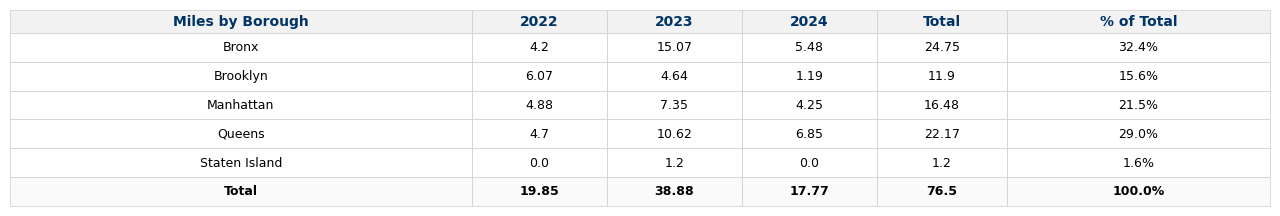

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.table import Table

# Data from your screenshot
data = {
    'Miles by Borough': ['Bronx', 'Brooklyn', 'Manhattan', 'Queens', 'Staten Island', 'Total'],
    '2022': [4.20, 6.07, 4.88, 4.70, 0.00, 19.85],
    '2023': [15.07, 4.64, 7.35, 10.62, 1.20, 38.88],
    '2024': [5.48, 1.19, 4.25, 6.85, 0.00, 17.77],
    'Total': [24.75, 11.90, 16.48, 22.17, 1.20, 76.50],
    '% of Total': ['32.4%', '15.6%', '21.5%', '29.0%', '1.6%', '100.0%']
}

# Convert data into a DataFrame
df = pd.DataFrame(data)

# Plot the table
fig, ax = plt.subplots(figsize=(10, 2.5))  # Flatter figure size
ax.axis('tight')
ax.axis('off')

# Add the table
table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    cellLoc='center',
    loc='center',
    colColours=["#003366"] * len(df.columns),  # Header background
)

# Style the table
table.auto_set_font_size(False)
table.set_fontsize(9)  # Smaller font for compact design
table.auto_set_column_width(col=list(range(len(df.columns))))  # Auto-adjust column widths

# Adjust row height and border line weight
for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#cccccc")  # Light gray borders
    cell.set_linewidth(0.5)  # Thinner lines for minimal design
    if row == 0:  # Header row
        cell.set_text_props(weight="bold", color="#003366", fontsize=10)  # Bold blue headers
        cell.set_facecolor("#f2f2f2")  # Light gray header background
        cell.set_height(0.12)  # Flatter header row
    elif row == len(df):  # Total row
        cell.set_text_props(weight="bold")
        cell.set_facecolor("#fafafa")  # Slight highlight for totals
        cell.set_height(0.15)  # Uniform row height
    else:
        cell.set_height(0.15)  # Reduced height for flatter rows

# Reduce padding for tighter cells
for row in range(len(df) + 1):  # +1 for the header
    for col in range(len(df.columns)):
        table[(row, col)].PAD = 1.2  # Minimal padding for flat cells

# Save as PNG
plt.savefig('bike_lane_lengths_flat_table_thin_lines.png', dpi=300, bbox_inches='tight')

# Display
plt.show()


In [142]:
import pandas as pd

# Load the dataset
file_path = '/Users/amyxqc/Desktop/amy_bikenycfall2024/Data/Bikelanelength/Streets Plan PBLs - ByMonth.csv'  # Update this with your actual file path
data = pd.read_csv(file_path)

print (data)


       Date  StreetsPlan Pipeline  SP Pipeline (Just City In-House)  \
0    1/1/22                  58.0                              39.0   
1    2/1/22                  58.0                              39.0   
2    3/1/22                  63.0                              43.0   
3    4/1/22                  67.0                              48.0   
4    5/1/22                  72.0                              52.0   
5    6/1/22                  88.0                              69.0   
6    7/1/22                  88.0                              69.0   
7    8/1/22                  88.0                              69.0   
8    9/1/22                  83.0                              65.0   
9   10/1/22                  83.0                              65.0   
10  11/1/22                  85.0                              68.0   
11  12/1/22                  79.0                              63.0   
12   1/1/23                  83.0                              63.0   
13   2

In [143]:
# Keep only the 'Month' and 'Complete' columns
data = data[['Year','Month', 'Date', 'Complete']]

# Display the filtered data
print(data)

      Year  Month     Date  Complete
0   2022.0    1.0   1/1/22       0.0
1   2022.0    2.0   2/1/22       0.0
2   2022.0    3.0   3/1/22       0.0
3   2022.0    4.0   4/1/22       1.0
4   2022.0    5.0   5/1/22       1.0
5   2022.0    6.0   6/1/22       3.0
6   2022.0    7.0   7/1/22       3.0
7   2022.0    8.0   8/1/22       4.0
8   2022.0    9.0   9/1/22       9.0
9   2022.0   10.0  10/1/22      13.0
10  2022.0   11.0  11/1/22      13.0
11  2022.0   12.0  12/1/22      20.0
12  2023.0    1.0   1/1/23      20.0
13  2023.0    2.0   2/1/23      20.0
14  2023.0    3.0   3/1/23      20.0
15  2023.0    4.0   4/1/23      24.0
16  2023.0    5.0   5/1/23      26.0
17  2023.0    6.0   6/1/23      26.0
18  2023.0    7.0   7/1/23      31.0
19  2023.0    8.0   8/1/23      32.0
20  2023.0    9.0   9/1/23      37.0
21  2023.0   10.0  10/1/23      39.0
22  2023.0   11.0  11/1/23      50.0
23  2023.0   12.0  12/1/23      59.0
24  2024.0    1.0   1/1/24      62.0
25  2024.0    2.0   2/1/24      62.0
2

In [144]:
print(data['Date'].isnull().sum())  # Check for null values


0


In [145]:
print(data['Date'].unique())  # Display unique values


['1/1/22' '2/1/22' '3/1/22' '4/1/22' '5/1/22' '6/1/22' '7/1/22' '8/1/22'
 '9/1/22' '10/1/22' '11/1/22' '12/1/22' '1/1/23' '2/1/23' '3/1/23'
 '4/1/23' '5/1/23' '6/1/23' '7/1/23' '8/1/23' '9/1/23' '10/1/23' '11/1/23'
 '12/1/23' '1/1/24' '2/1/24' '3/1/24' '4/1/24' '5/1/24' '6/1/24' '7/1/24'
 '8/1/24' '9/1/24' '10/1/24' '11/1/24' '12/1/24' '1/1/25']


In [146]:
data['Date'] = pd.to_datetime(data['Date'], format='%m/%d/%y', errors='coerce')



In [147]:
print(data['Date'].head())
print(data['Date'].dtype)


0   2022-01-01
1   2022-02-01
2   2022-03-01
3   2022-04-01
4   2022-05-01
Name: Date, dtype: datetime64[ns]
datetime64[ns]


In [153]:
start_date = pd.Timestamp('2022-01-01')

data['Year'] = data['Date'].dt.year  # Extract 4-digit year
data['Month_Number'] = data['Date'].dt.month  # Extract month number
data['Week_Number'] = ((data['Date'] - start_date).dt.days // 7) + 1


In [154]:
filtered_data = data[['Date', 'Year', 'Month_Number', 'Week_Number', 'Complete']]
print(filtered_data)  # Display the processed data


         Date  Year  Month_Number  Week_Number  Complete
0  2022-01-01  2022             1            1       0.0
1  2022-02-01  2022             2            5       0.0
2  2022-03-01  2022             3            9       0.0
3  2022-04-01  2022             4           13       1.0
4  2022-05-01  2022             5           18       1.0
5  2022-06-01  2022             6           22       3.0
6  2022-07-01  2022             7           26       3.0
7  2022-08-01  2022             8           31       4.0
8  2022-09-01  2022             9           35       9.0
9  2022-10-01  2022            10           40      13.0
10 2022-11-01  2022            11           44      13.0
11 2022-12-01  2022            12           48      20.0
12 2023-01-01  2023             1           53      20.0
13 2023-02-01  2023             2           57      20.0
14 2023-03-01  2023             3           61      20.0
15 2023-04-01  2023             4           66      24.0
16 2023-05-01  2023            

In [225]:
# Add a new column `FullLength` by adding 650 to the `Complete` column
filtered_data['FullLength'] = filtered_data['Complete'] + 1350

# Display the updated DataFrame
print(filtered_data)

         Date  Year  Month_Number  Week_Number  Complete  FullLength
0  2022-01-01  2022             1            1       0.0      1350.0
1  2022-02-01  2022             2            5       0.0      1350.0
2  2022-03-01  2022             3            9       0.0      1350.0
3  2022-04-01  2022             4           13       1.0      1351.0
4  2022-05-01  2022             5           18       1.0      1351.0
5  2022-06-01  2022             6           22       3.0      1353.0
6  2022-07-01  2022             7           26       3.0      1353.0
7  2022-08-01  2022             8           31       4.0      1354.0
8  2022-09-01  2022             9           35       9.0      1359.0
9  2022-10-01  2022            10           40      13.0      1363.0
10 2022-11-01  2022            11           44      13.0      1363.0
11 2022-12-01  2022            12           48      20.0      1370.0
12 2023-01-01  2023             1           53      20.0      1370.0
13 2023-02-01  2023             2 

In [222]:
# Save filtered data to CSV
filtered_data.to_csv("/Users/amyxqc/Desktop/amy_bikenycfall2024/Data/filtered_bike_lane_data.csv", index=False)

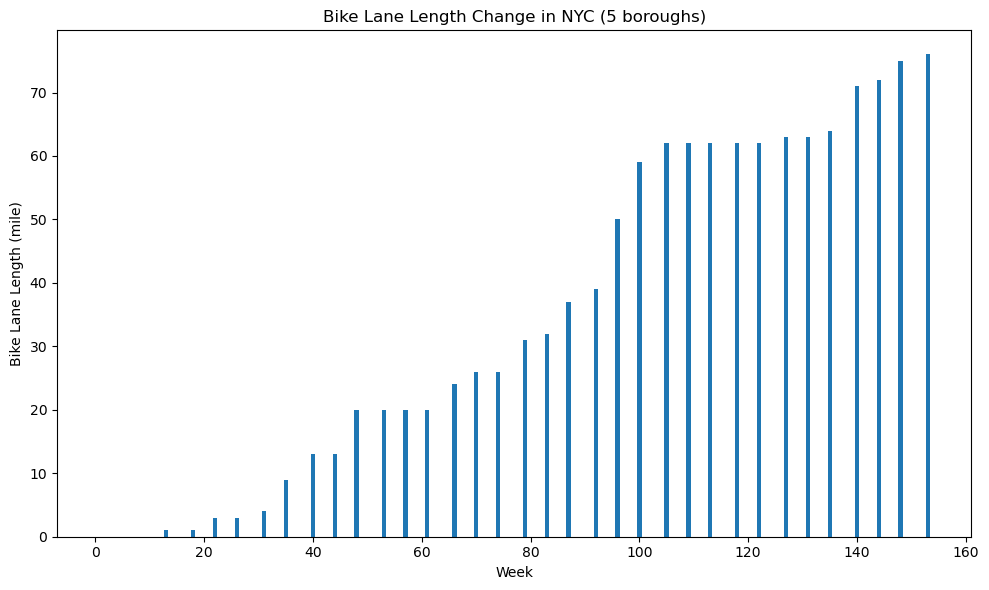

In [165]:
# Plot the data
plt.figure(figsize=(10, 6))
plt.bar(filtered_data["Week_Number"], filtered_data["Complete"], width=0.8)
plt.title("Bike Lane Length Change in NYC (5 boroughs)")
plt.xlabel("Week")
plt.ylabel("Bike Lane Length (mile)")
plt.tight_layout()
plt.show()

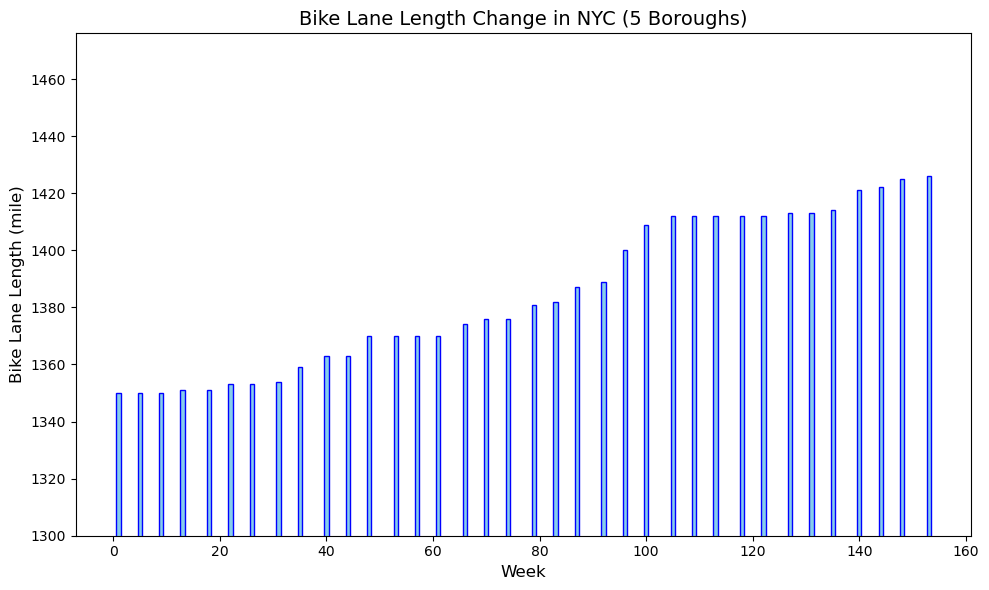

In [229]:
# Assuming `filtered_data` is already loaded and contains the required columns
plt.figure(figsize=(10, 6))

# Plot the bar chart
plt.bar(filtered_data["Week_Number"], filtered_data["FullLength"], width=0.8, color="skyblue", edgecolor="blue")

# Add title and labels
plt.title("Bike Lane Length Change in NYC (5 Boroughs)", fontsize=14)
plt.xlabel("Week", fontsize=12)
plt.ylabel("Bike Lane Length (mile)", fontsize=12)

# Set y-axis limit
plt.ylim(1300, filtered_data["FullLength"].max() + 50)  # Adjust the upper limit slightly above the max value

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()